# Variational Autoencoders (VAEs)

Variational Autoencoders (VAEs) are a type of generative model that learn to encode data into a latent space and then decode from that space to reconstruct the data. VAEs are a probabilistic extension of traditional autoencoders and are designed to learn the underlying distribution of the data [1].

## Key Concepts

1. **Latent Variables**: VAEs introduce a set of latent variables $\mathbf{z}$ that represent the underlying structure of the data $\mathbf{x}$.
2. **Encoder (Inference Model)**: Maps input data $\mathbf{x}$ to a distribution over the latent variables $q_\phi(\mathbf{z}|\mathbf{x})$.
3. **Decoder (Generative Model)**: Maps latent variables $\mathbf{z}$ back to the data space, generating reconstructed data $p_\theta(\mathbf{x}|\mathbf{z})$.
4. **Prior Distribution**: The latent variables $\mathbf{z}$ are assumed to follow a prior distribution, typically a standard normal distribution $p(\mathbf{z}) = \mathcal{N}(\mathbf{z}; 0, \mathbf{I})$.

## Objective Function

The objective of a VAE is to maximize the Evidence Lower Bound (ELBO) on the marginal likelihood of the data [2]:

$$ \log p_\theta(\mathbf{x}) \geq \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} \left[ \log p_\theta(\mathbf{x}|\mathbf{z}) \right] - \text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z})) $$

This ELBO consists of two terms:

1. **Reconstruction Term**: $\mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} \left[ \log p_\theta(\mathbf{x}|\mathbf{z}) \right]$
2. **KL Divergence Term**: $\text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}))$.

### Reconstruction Term

The reconstruction term ensures that the decoded data is similar to the input data. This term can be viewed as a negative reconstruction error. In practice, for continuous data, it is often assumed that:

$$ p_\theta(\mathbf{x}|\mathbf{z}) = \mathcal{N}(\mathbf{x}; \mathbf{\mu}_\theta(\mathbf{z}), \sigma^2 \mathbf{I}) $$

The reconstruction term then becomes:

$$ \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} \left[ \log \mathcal{N}(\mathbf{x}; \mathbf{\mu}_\theta(\mathbf{z}), \sigma^2 \mathbf{I}) \right] $$

### KL Divergence Term

The KL divergence term regularizes the encoder to produce a latent distribution $q_\phi(\mathbf{z}|\mathbf{x})$ that is close to the prior $p(\mathbf{z})$ [3]:

$$ \text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z})) = \int q_\phi(\mathbf{z}|\mathbf{x}) \log \frac{q_\phi(\mathbf{z}|\mathbf{x})}{p(\mathbf{z})} d\mathbf{z} $$

For a Gaussian prior and posterior, this term can be computed analytically.

## Variational Inference

To optimize the ELBO, we use variational inference. The encoder outputs the parameters of the posterior distribution $q_\phi(\mathbf{z}|\mathbf{x})$, typically the mean $\mathbf{\mu}_\phi(\mathbf{x})$ and variance $\mathbf{\sigma}_\phi(\mathbf{x})$ of a Gaussian distribution:

$$ q_\phi(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\mathbf{z}; \mathbf{\mu}_\phi(\mathbf{x}), \text{diag}(\mathbf{\sigma}_\phi^2(\mathbf{x}))) $$

## Reparameterization Trick

To backpropagate through the stochastic sampling of $\mathbf{z}$, the reparameterization trick is used [1]. Instead of sampling $\mathbf{z}$ directly from $q_\phi(\mathbf{z}|\mathbf{x})$, we sample an auxiliary noise variable $\mathbf{\epsilon}$ from a standard normal distribution and transform it:

$$ \mathbf{z} = \mathbf{\mu}_\phi(\mathbf{x}) + \mathbf{\sigma}_\phi(\mathbf{x}) \odot \mathbf{\epsilon}, \quad \mathbf{\epsilon} \sim \mathcal{N}(0, \mathbf{I}) $$

This allows gradients to propagate through $\mathbf{\mu}_\phi(\mathbf{x})$ and $\mathbf{\sigma}_\phi(\mathbf{x})$ during training.

## Summary

The VAE learns to encode data $\mathbf{x}$ into a latent space $\mathbf{z}$ and decode $\mathbf{z}$ back to $\mathbf{x}$ while ensuring the latent space follows a standard normal distribution. The objective function combines a reconstruction error term and a regularization term to achieve this [4]:

$$ \mathcal{L}(\mathbf{x}) = \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})} \left[ \log p_\theta(\mathbf{x}|\mathbf{z}) \right] - \text{KL}(q_\phi(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z})) $$

Optimizing this loss function results in a VAE that can generate new data points by sampling from the latent space and decoding them.

## References

1. Kingma, D. P., & Welling, M. (2013). Auto-Encoding Variational Bayes. arXiv preprint arXiv:1312.6114.
2. Doersch, C. (2016). Tutorial on Variational Autoencoders. arXiv preprint arXiv:1606.05908.
3. Rezende, D. J., Mohamed, S., & Wierstra, D. (2014). Stochastic Backpropagation and Approximate Inference in Deep Generative Models. arXiv preprint arXiv:1401.4082.
4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

In [3]:
!pip install torch==2.1.0 torchvision torchviz

  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4132 sha256=8a51b0d2392361de4050d054d0256a96ac242f585a1a6e20c6329c7e2b5c7e33
  Stored in directory: /root/.cache/pip/wheels/4c/97/88/a02973217949e0db0c9f4346d154085f4725f99c4f15a87094
Successfully built torchviz


Train Epoch: 1 [0/60000 (0%)]	Loss: 544.808105
Train Epoch: 1 [12800/60000 (21%)]	Loss: 191.803116
Train Epoch: 1 [25600/60000 (43%)]	Loss: 179.080673
Train Epoch: 1 [38400/60000 (64%)]	Loss: 154.041595
Train Epoch: 1 [51200/60000 (85%)]	Loss: 140.265778
====> Epoch: 1 Average loss: 175.0086
Train Epoch: 2 [0/60000 (0%)]	Loss: 139.771805
Train Epoch: 2 [12800/60000 (21%)]	Loss: 127.949661
Train Epoch: 2 [25600/60000 (43%)]	Loss: 127.365158
Train Epoch: 2 [38400/60000 (64%)]	Loss: 125.114548
Train Epoch: 2 [51200/60000 (85%)]	Loss: 125.058884
====> Epoch: 2 Average loss: 127.3993
Train Epoch: 3 [0/60000 (0%)]	Loss: 125.137199
Train Epoch: 3 [12800/60000 (21%)]	Loss: 117.011925
Train Epoch: 3 [25600/60000 (43%)]	Loss: 119.176300
Train Epoch: 3 [38400/60000 (64%)]	Loss: 115.018066
Train Epoch: 3 [51200/60000 (85%)]	Loss: 120.043793
====> Epoch: 3 Average loss: 117.2240
Train Epoch: 4 [0/60000 (0%)]	Loss: 112.787949
Train Epoch: 4 [12800/60000 (21%)]	Loss: 118.325226
Train Epoch: 4 [25600/

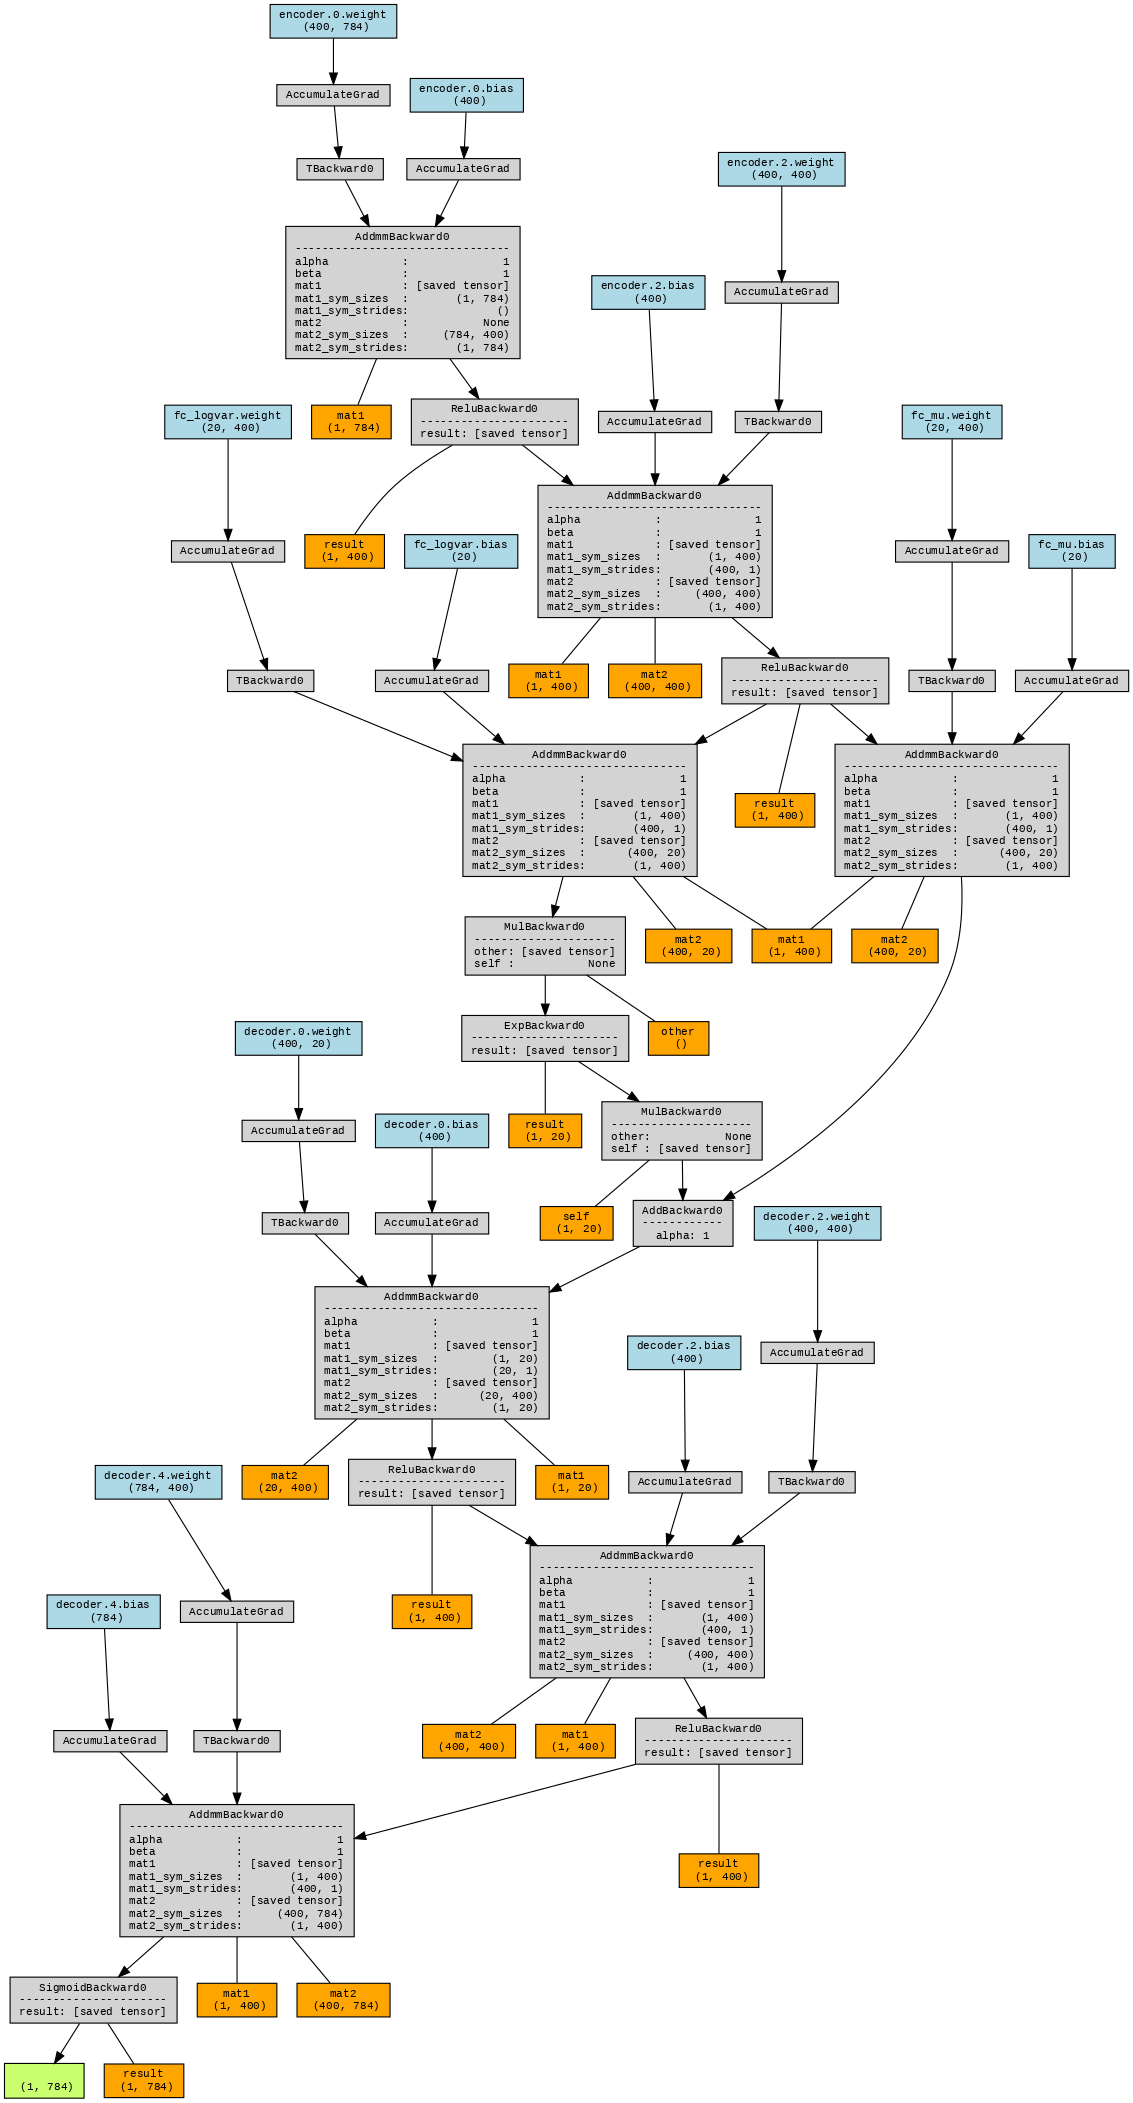

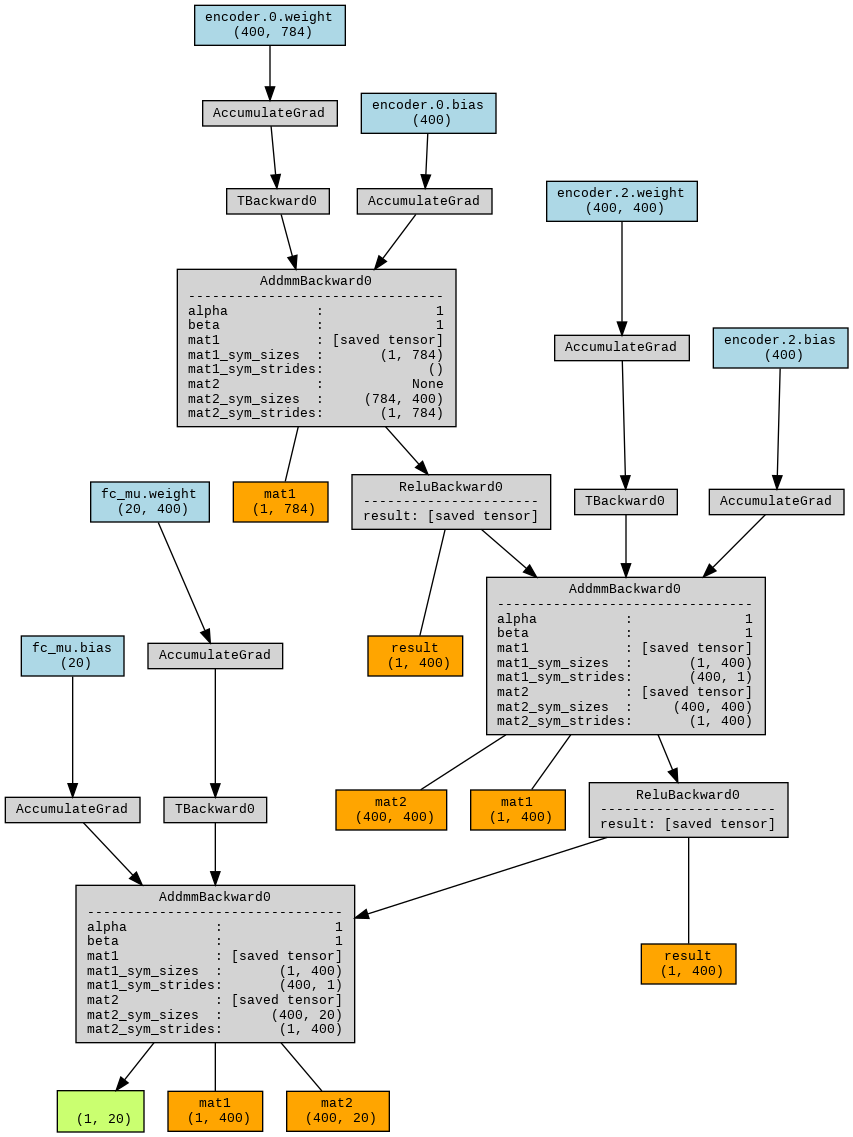

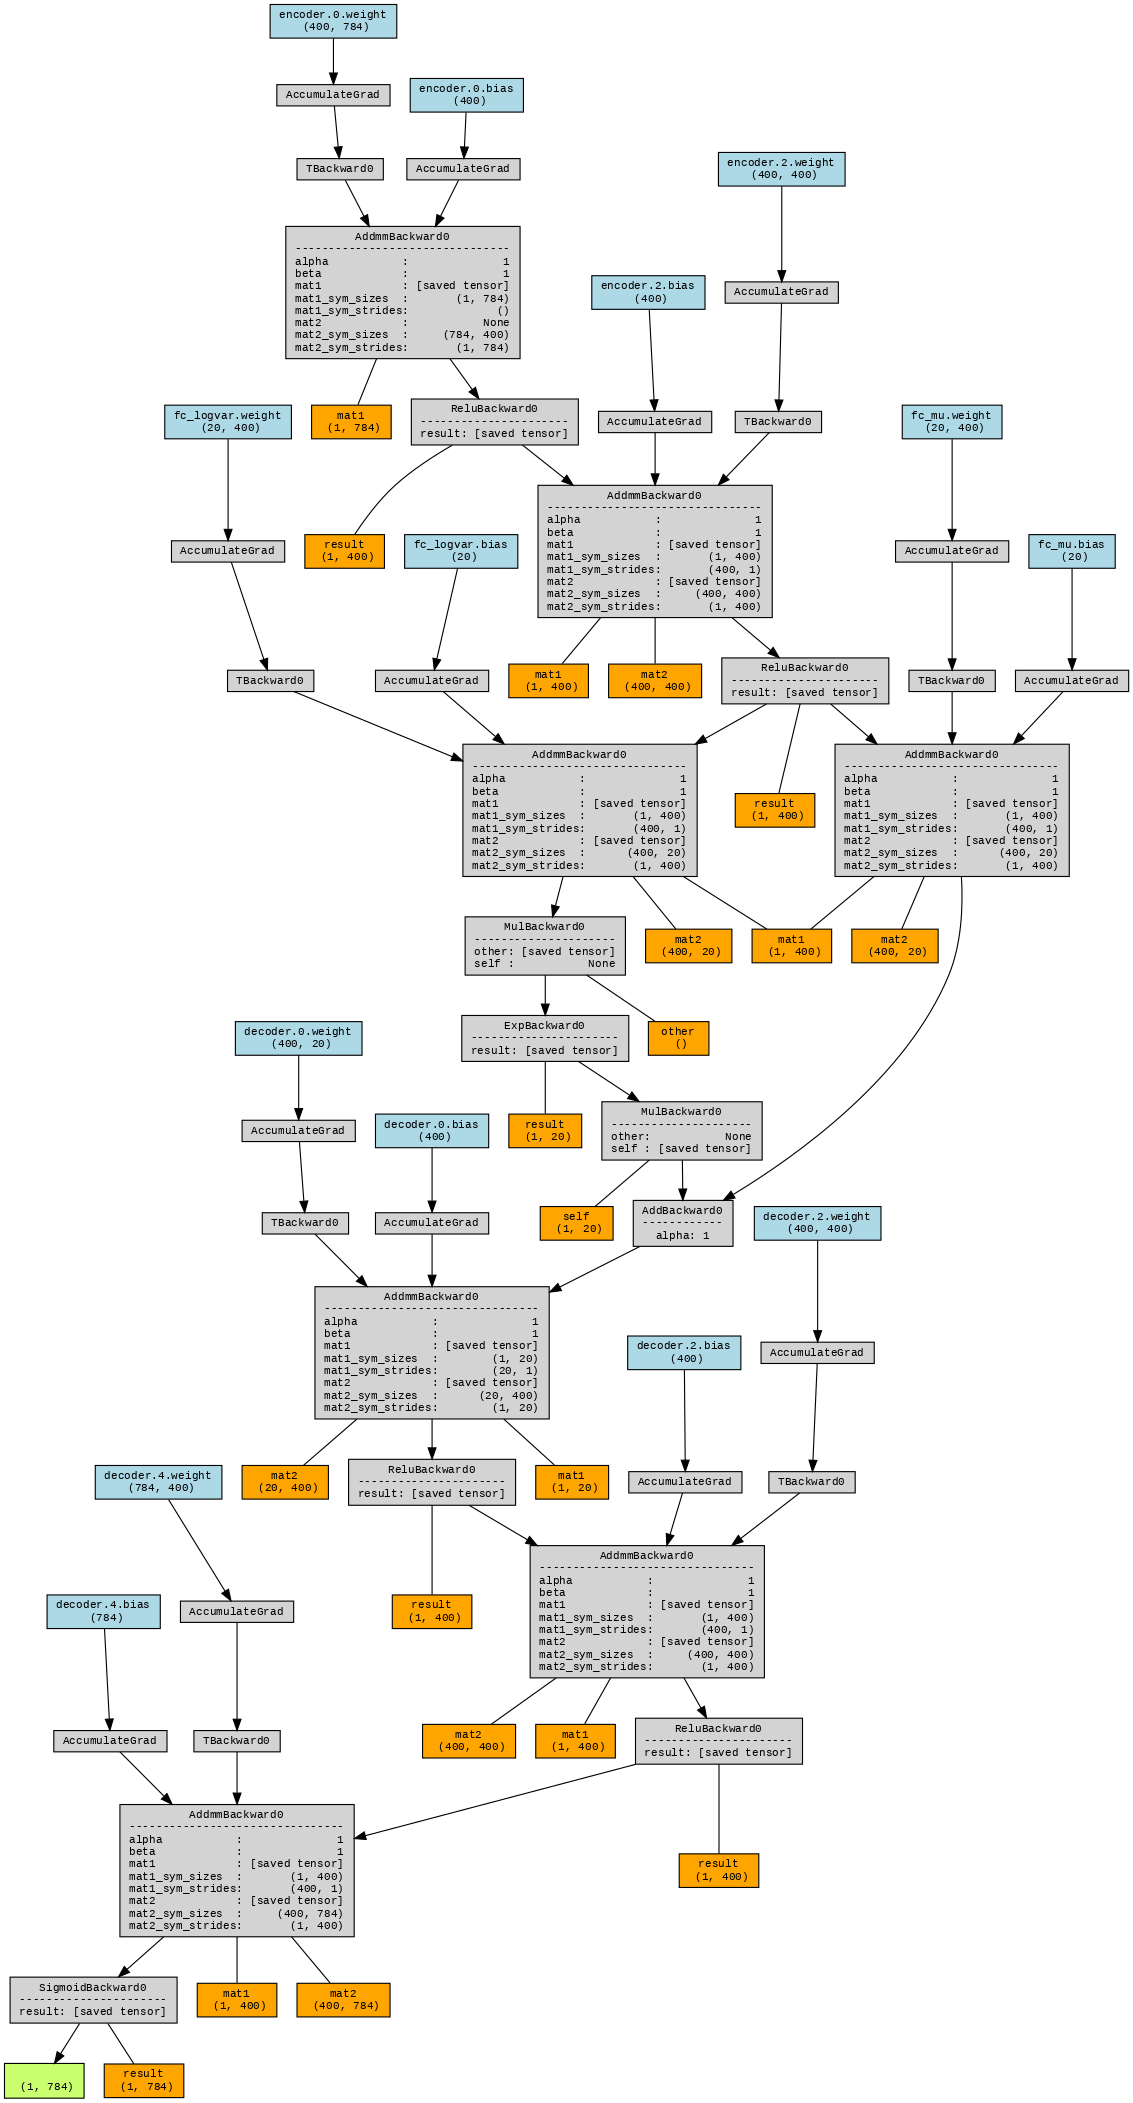

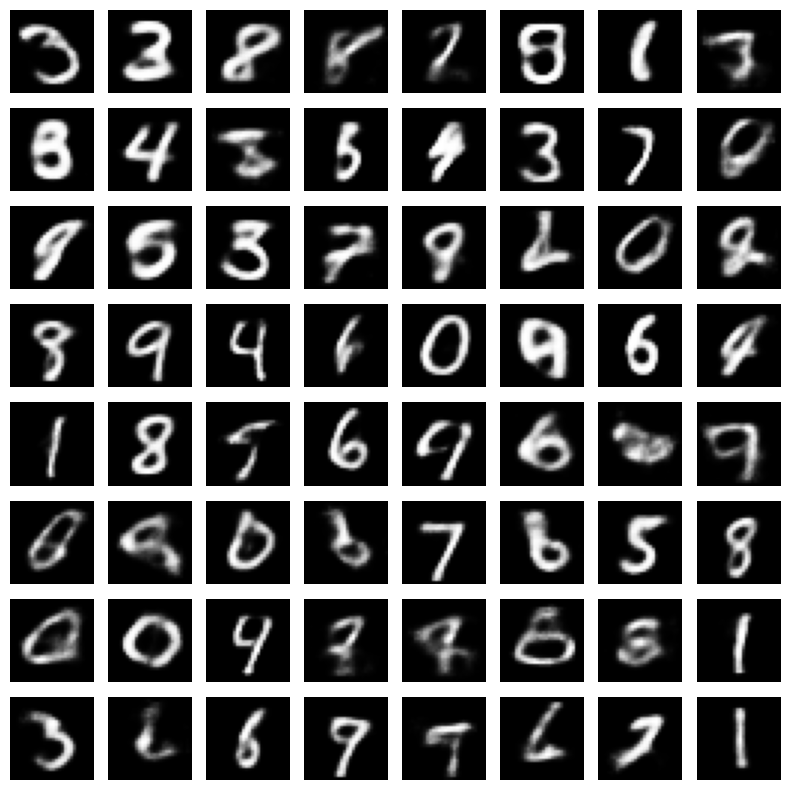

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchviz import make_dot
from IPython.display import Image, display

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the VAE model
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Mean and log variance layers
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # For MNIST images (values between 0 and 1)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss function
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Training function
def train(model, train_loader, optimizer, epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device).view(data.size(0), -1)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')

    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Visualization function
def visualize_model(model):
    x = torch.randn(1, 784).to(device)
    y, mu, logvar = model(x)

    # Visualize full model
    dot = make_dot(y, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)
    dot.render("vae_model_graph", format="png")
    display(Image("vae_model_graph.png"))

    # Visualize encoder
    dot_encoder = make_dot(mu, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)
    dot_encoder.render("vae_encoder_graph", format="png")
    display(Image("vae_encoder_graph.png"))

    # Visualize decoder
    z = model.reparameterize(mu, logvar)
    y_decoded = model.decode(z)
    dot_decoder = make_dot(y_decoded, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)
    dot_decoder.render("vae_decoder_graph", format="png")
    display(Image("vae_decoder_graph.png"))

# Main execution
def main():
    # Hyperparameters
    input_dim = 784  # 28x28 MNIST images
    hidden_dim = 400
    latent_dim = 20
    batch_size = 128
    epochs = 10

    # Load MNIST dataset
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialize the model
    model = VAE(input_dim, hidden_dim, latent_dim).to(device)
    optimizer = optim.Adam(model.parameters())

    # Train the model
    for epoch in range(1, epochs + 1):
        train(model, train_loader, optimizer, epoch)

    # Visualize the model
    visualize_model(model)

    # Generate some samples
    with torch.no_grad():
        sample = torch.randn(64, latent_dim).to(device)
        sample = model.decode(sample).cpu()

        plt.figure(figsize=(8, 8))
        for i in range(64):
            plt.subplot(8, 8, i + 1)
            plt.imshow(sample[i].reshape(28, 28), cmap='gray')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()